


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados
- Primeiro vou importar as bibliotecas que irão serem usadas no projeto.
- Ler todos os DataFrame separadamente com o pd.read_csv() e usando o separador ';'.
- Para o DataFrame order_products.csv que contém muitas linhas, foi usado o show_counts=True como parâmetro dentro do info para que o info() pudesse mostrar todos os valores não nulos.

In [ ]:
# Importe as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# leia os conjuntos de dados em DataFrames
# Extraindo cada arquivo csv usando o pd.read_csv com separador ';'
instacart_orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')

departments = pd.read_csv('/datasets/departments.csv', sep=';')

# Imprimindo as primeiras 5 linhas de cada DataFrame
print(instacart_orders.head())
print()
print(products.head())
print()
print(order_products.head())
print()
print(aisles.head())
print()
print(departments.head())

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                   

In [ ]:
# imprima as informações sobre o DataFrame
instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [ ]:
# imprima as informações sobre o DataFrame
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
# imprima as informações sobre o DataFrame
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [ ]:
# imprima as informações sobre o DataFrame
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
# imprima as informações sobre o DataFrame
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados

- Após a visualização dos primeiros dados, é possível verificar que existem valores ausentes em três dos cinco DataFrame, por sinal, os DataFrame de maiores volumes de dados que precisarão de tratamento para esses valores ausentes e possíveis duplicados.

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados
- Após a extração dos dados e identificação de valores ausentes, vamos para a preparação dos dados.
- Transformar colunas de strings para minúsculas como o str.lower().
- Verificar e corrigir valores com duplicidades explicitas e implicitas.
- Corrigir valores ausentes inserindo algum valor ou exclui-lo caso necessário.
- Verificar se existem outras anomalias nos DataFrames.

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [ ]:
# Verificar se há pedidos duplicados

print(instacart_orders['order_id'].duplicated().sum()) # Visualiza a quantidade de duplicados
# Visualizando as colunas duplicadas
duplicados = instacart_orders[instacart_orders['order_id'].duplicated()]
print(duplicados)

15
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48         

Há linhas duplicadas? Se sim, o que elas têm em comum?
- Sim. Existem 14 duplicados nas colunas 'order_id', 'order_dow' e 'order_hour_of_day'.

In [ ]:
# Com base nas suas conclusões,
# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras
pedidos_quarta_2hs = instacart_orders[(instacart_orders['order_dow'] == 3) & (instacart_orders['order_hour_of_day'] == 2)]
print(pedidos_quarta_2hs)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

O que esse resultado quer dizer?
- O resultado mostra o porque de existirem duplicados. Os valores das colunas 'order_dow' e 'order_hour_of_day' foram inseridos duas vezes para o mesmo pedido, que por sua vez é um valor único.

In [ ]:
# Remova pedidos duplicados
instacart_orders = instacart_orders.drop_duplicates(subset=['order_id']).reset_index(drop=True)

In [ ]:
# Verifique as linhas duplicadas mais uma vez
print(instacart_orders['order_id'].duplicated().sum())

0


In [ ]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(instacart_orders[(instacart_orders['order_dow'] == 3) & (instacart_orders['order_hour_of_day'] == 2)])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
456998   3384021    14881             6          3                  2   
458801    910166   164782            18          3                  2   
459620   1680532   106435             6          3                  2   
468309    222962    54979            59          3                  2   
477511   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

In [ ]:
instacart_orders[instacart_orders['order_id'].duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Descreva brevemente suas conclusões e o que você fez com elas.
- Conclui que foram inseridos de forma duplicadas em 14 IDs de pedidos para o mesmo dia e horário, gerando informação desnecessária.
- Fiz a exclusão desses dados duplicados usando o método drop_duplicates()

### DataFrame `products`

In [ ]:
# Verifique se há linhas completamente duplicadas
print(products.duplicated().sum())

0


In [ ]:
# Verifique apenas IDs dos produtos duplicados
print(products['product_id'].duplicated().sum())

0


In [ ]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
products['product_name'] = products['product_name'].str.lower()
print(products['product_name'].duplicated().sum())

1361


In [ ]:
# Verifique os nomes de produtos duplicados que não estão faltando
# Criando variável para armazenar os produtos duplicados não NaN
product_name = products[products['product_name'].notna()]
# Obtendo a quantidade de nomes duplicados
nomes_duplicados = product_name[product_name['product_name'].duplicated()]
# Visualizando
print(nomes_duplicados)

       product_id                                     product_name  aisle_id  \
2058         2059                                  biotin 1000 mcg        47   
5455         5456                 green tea with ginseng and honey        96   
5558         5559                           cream of mushroom soup        69   
7558         7559                        cinnamon rolls with icing       105   
9037         9038                           american cheese slices        21   
...           ...                                              ...       ...   
49689       49690                    high performance energy drink        64   
49690       49691                    original pancake & waffle mix       130   
49691       49692  organic instant oatmeal light maple brown sugar       130   
49692       49693                           spring water body wash       127   
49693       49694                          burrito- steak & cheese        38   

       department_id  
2058            

Descreva brevemente suas conclusões e o que você fez com elas.
- Foi possível visualizar que não existem linhas completamente duplicadas, que existem 1361 linhas duplicadas para a coluna 'product_name', sendo dessas apenas 104 linhas com nomes duplicados que não são NaN.

### DataFrame `departments`

In [ ]:
# Verifique se há linhas completamente duplicadas
print(departments.duplicated().sum())

0


In [ ]:
# Verifique apenas IDs duplicados de departamentos
print(departments['department_id'].duplicated().sum())

0


Descreva brevemente suas conclusões e o que você fez com elas.
- O DataFrame departments só existem duas colunas e 21 linhas, sendo nenhuma delas iguais, portanto todas estão ok.

### DataFrame `aisles`

In [ ]:
# Verifique se há linhas completamente duplicadas
print(aisles.duplicated().sum())

0


In [ ]:
# Verifique apenas IDs duplicados de corredores
print(aisles['aisle_id'].duplicated().sum())

0


Descreva brevemente suas conclusões e o que você fez com elas.
- O DataFrame aisles também não apresenta valores duplicados. Contendo apenas duas colunas e 134 linhas se repetições.

### DataFrame `order_products`

In [ ]:
# Verifique se há linhas completamente duplicadas
print(order_products.duplicated().sum())

0


In [ ]:
# Verifique mais uma vez se há outros casos complicados de duplicados
# Visualizando por colunas de id e a ordem de sequência de cada item colocado no carrinho.
duplicados_colunas = order_products.duplicated(subset= ['order_id', 'add_to_cart_order']).sum()
# Visualizando o resultado
print(duplicados_colunas)

766


Descreva brevemente suas conclusões e o que você fez com elas.
- Analisando o DataFrame order_products, foi visto que não existem nenhum dado com duplicidade explicita, no entanto ao analisar colunas que se relacionam podemos ver que existem 766 duplicados implícitos.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [ ]:
# Encontre valores ausentes na coluna 'product_name'
print(products['product_name'].isna().sum())

1258


Descreva brevemente suas conclusões.
- Existem 1258 linhas com valores ausentes que precisam serem vistas e corrigidas.

In [ ]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
print(products[products['product_name'].isna()]['aisle_id'].unique())

[100]


Descreva brevemente suas conclusões.
- Sim, todos os produtos com valores ausentes estão associados ao corredor de ID 100.

In [ ]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
print(products[products['product_name'].isna()]['department_id'].unique())

[21]


Descreva brevemente suas conclusões.
- Sim, todos os produtos com valores ausentes estão associados ao corredor de ID 21.

In [ ]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
# Filtrando a coluna aisle_id do DataFrame aisles que o ID seja igual a 100.
corredor_100 = aisles[aisles['aisle_id'] == 100]
# Filtrando a coluna department_id do DataFrame products que o ID seja igual a 21
department_21 = products[products['department_id'] == 21]
# Imprimindo os valores de aisle_id
print(corredor_100)
print('---------------------------------')
# Imprimindo os valores de department_id
print(department_21)

    aisle_id    aisle
99       100  missing
---------------------------------
       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Descreva brevemente suas conclusões.
- Foi observado que existem 1258 linhas com valores ausentes na coluna 'product_name', com todos eles no corredor de ID 100 e department de ID 21.

In [ ]:
# Preencha nomes de produtos ausentes com 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print(products['product_name'].isna().sum())

0


Descreva brevemente suas conclusões e o que você fez com elas.
- Existiam 1258 linhas com valores ausentes. Esses valores era na coluna 'product_name'. Fiz a alteração substituindo os valores ausentes NaN por 'Unknown' usando o fillna().

### DataFrame `instacart_orders`

In [ ]:
# Encontre os valores ausentes
print(instacart_orders.isna().sum())

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [ ]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
# Extraindo todos os pedidos que não foram os primeiros
pedidos_nao_foi_primeiro = instacart_orders[instacart_orders['order_number'] > 1]
# Verificando se existe valor ausente para pedidos que ainda não foram feitos
valores_ausentes_nao_primeiro = pedidos_nao_foi_primeiro['days_since_prior_order'].isna().sum()
# imprimindo o resultado
print(f'Pedidos que não são o primeiro {len(pedidos_nao_foi_primeiro)}')
print(f'Valores ausentes que não foram o primeiro {valores_ausentes_nao_primeiro}')


Pedidos que não são o primeiro 450135
Valores ausentes que não foram o primeiro 0


Descreva brevemente suas conclusões e o que você fez com elas.
- Existem 28817 valores ausentes para days_since_prior_order, que são clientes que ainda estavam fazendo o primeiro pedido. Foi verificado que não existe nada errado com essa coluna.

### DataFrame `order_products`

In [ ]:
# Encontre os valores ausentes
print(order_products.isna().sum())

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [ ]:
# Quais são os valores mínimo e máximo dessa coluna (add_to_cart_order)?
# Obtendo o valor mínimo da coluna add_to_cart_order
vlr_min = order_products['add_to_cart_order'].min()
# Obtendo o valor máximo da coluna add_to_cart_orders
vlr_max = order_products['add_to_cart_order'].max()

print(f'O valor mínimo da coluna add_to_cart_orders é {vlr_min}')
print(f'O valor máximo da coluna add_to_cart_orders é {vlr_max}')

O valor mínimo da coluna add_to_cart_orders é 1.0
O valor máximo da coluna add_to_cart_orders é 64.0


Descreva brevemente suas conclusões.
- No DataFrame order_products existem 836 linhas com valores ausentes, todos na coluna 'add_to_cart_order', sendo o valor mínimo 1.0 e o valor máximo 64.0.

In [ ]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
pedidos_com_valores_ausentes = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
# Imprimindo o resultado
print(f' Os IDs dos pedidos com pelo menos um valor ausente em add_to_cart_order são {len(pedidos_com_valores_ausentes)}')
print(f'Imprimindo os 15 primeiros valores: {pedidos_com_valores_ausentes[:15]}')

 Os IDs dos pedidos com pelo menos um valor ausente em add_to_cart_order são 70
Imprimindo os 15 primeiros valores: [2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010]


In [ ]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
# Agrupe os pedidos com dados ausentes por ID de pedido
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
# Filtrando as ordens dos pedidos usando como parâmetro a variável criada na celula anterior
pedidos_completos_com_nulos = order_products[order_products['order_id'].isin(pedidos_com_valores_ausentes)]
# Agrupando os pedidos por ID e contamos quantos produtos (product_id) existem em cada um
contagem_de_produtos = pedidos_completos_com_nulos.groupby('order_id')['product_id'].count()

# Verificamos qual é o valor mínimo dessa contagem
valor_minimo_contagem = contagem_de_produtos.min()
# Verificando se todos são maiores que 64
todos_mais_de_64 = valor_minimo_contagem > 64

# RESPONDER AOS QUESTIONAMENTOS
print(f"Número de pedidos analisados (com dados ausentes): {len(contagem_de_produtos)}")
print(f"O valor mínimo de produtos encontrados nesses pedidos é: {valor_minimo_contagem}")
print(f"Todos os pedidos com valores ausentes contêm mais de 64 produtos? {todos_mais_de_64}")

Número de pedidos analisados (com dados ausentes): 70
O valor mínimo de produtos encontrados nesses pedidos é: 65
Todos os pedidos com valores ausentes contêm mais de 64 produtos? True


Descreva brevemente suas conclusões.
- Foi concluido que a coluna 'add_to_cart_order' só armazena valores de 1 a 64, fazendo com que os valores acima de 64 sejam lançados como NaN, indicando uma possível limitação do sistema.


In [ ]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
# Substituindo os valores ausentes por 999
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)
# Convertendo de float para int
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

# Imprimindo os resultadod
print('Visualisando os resultados:')
order_products.info()

Visualisando os resultados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


Descreva brevemente suas conclusões e o que você fez com elas.
- Haviam linhas da coluna 'add_to_cart_order' com valores ausentes. Foi feito a substituição desses valores ausentes 'NaN' por 999 e após isso foi convertido o tipo de float para int.


## Conclusões
Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados
- A etapa de preparação tivemos que realizar uma série de correções nos dados.
- Foi identificado e corrigido valores ausentes.
- Verificado o motivo pelo o qual a coluna 'add_to_cart_order' do DataFrame order_products continha valores ausentes. Isso acontecia porque a coluna só suporta valores que vão de 1 a 64, fazendo com que todos os valores acima de 64 ficassem com valor NaN.
- No Dataframe products, na coluna 'product_name' existiam valores ausentes onde foram substituidos por 'Unknown'. Esses valores são produtos que provavelmente foram cadastrados no sistema, mas esqueceram de inserir o nome para cada um deles.

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [ ]:
horas_unicas = sorted(instacart_orders['order_hour_of_day'].unique())
dias_unicos = sorted(instacart_orders['order_dow'].unique())

print('Esses são todas as horas únicas que tem na coluna order_hour_of_day')
print(horas_unicas)
print('Esses são todos os dias únicos que tem na coluna order_dow')
print(dias_unicos)
print('Portanto todos os dias e horas fazem sentido, pois estão dentro da variação desejada')

Esses são todas as horas únicas que tem na coluna order_hour_of_day
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Esses são todos os dias únicos que tem na coluna order_dow
[0, 1, 2, 3, 4, 5, 6]
Portanto todos os dias e horas fazem sentido, pois estão dentro da variação desejada


Escreva suas conclusões aqui
- Foi concluido que todos os valores de dias e horas fazem sentido pois estão dentro do que foi definido.

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

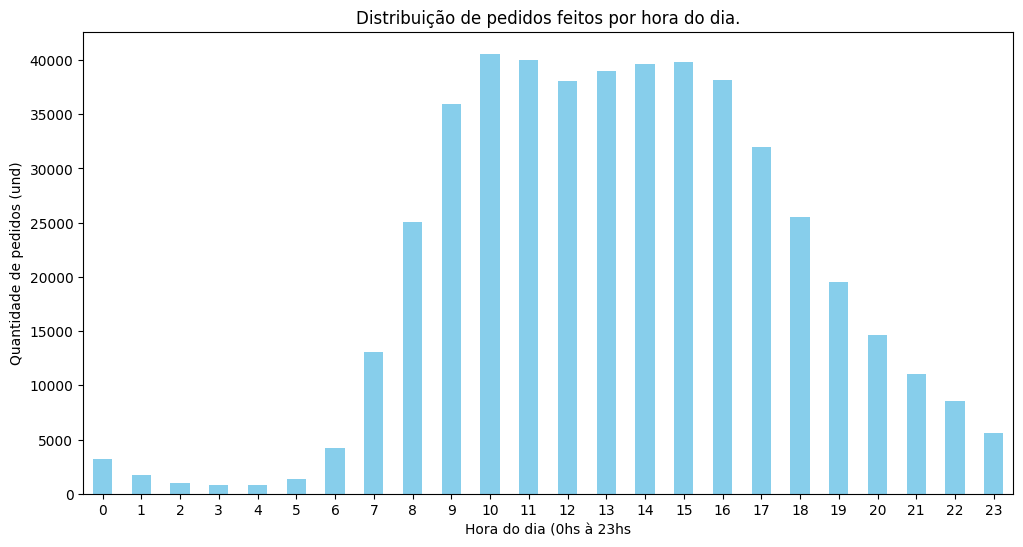

0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


In [ ]:

# Criando a variável para verificar os pedidos por hora
pedidos_por_hora = instacart_orders['order_hour_of_day'].value_counts().sort_index()

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
pedidos_por_hora.plot(kind= 'bar', color= 'skyblue')
plt.title('Distribuição de pedidos feitos por hora do dia.')
plt.xlabel('Hora do dia (0hs à 23hs')
plt.ylabel('Quantidade de pedidos (und)')
plt.xticks(rotation= 0)
plt.show()

# Imprimindo
print(pedidos_por_hora)


Escreva suas conclusões aqui
- Podemos perceber que nas primeiras horas o volume de pedidos é bem menor, assim no final do dia, onde os pedidos também baixam.
- O pico se concentra entre as horas 9 e 17, com volumes acimas dos 30 mil pedidos.

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

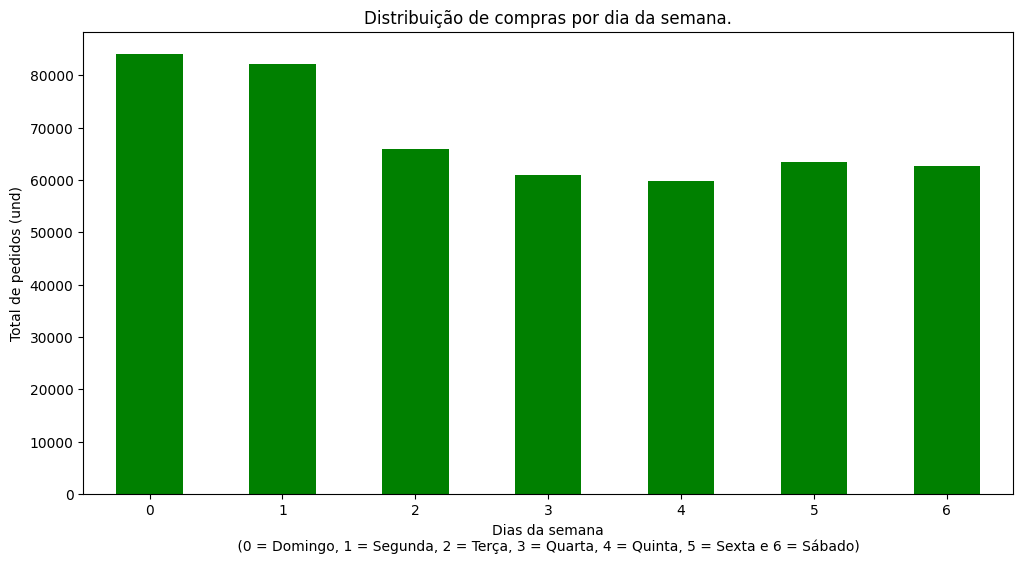

-----------------------------------
0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64


In [ ]:


# Criando a variável para verificar a quantidade que as pessoas compram em cada dia da semana
pedidos_por_dia = instacart_orders['order_dow'].value_counts().sort_index()

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
grafico_dias = pedidos_por_dia.plot(kind= 'bar', color= 'green')
plt.title('Distribuição de compras por dia da semana.')
plt.xlabel('Dias da semana\n (0 = Domingo, 1 = Segunda, 2 = Terça, 3 = Quarta, 4 = Quinta, 5 = Sexta e 6 = Sábado) ')
plt.ylabel('Total de pedidos (und)')
plt.xticks(rotation= 0)
plt.show()

# Imprimindo
print('-----------------------------------')
print(pedidos_por_dia)

Escreva suas conclusões aqui
- Foi identificado que Domingo e Segunda são os dias em que as pessoas mais fazem compras de alimentos.
- Em contra-partida nos dias de Quarta e Quinta são os dias em que se tem menos compras, podendo posteriormente se fazer alguma ação de marketing para atrair mais clientes para esses dias.

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

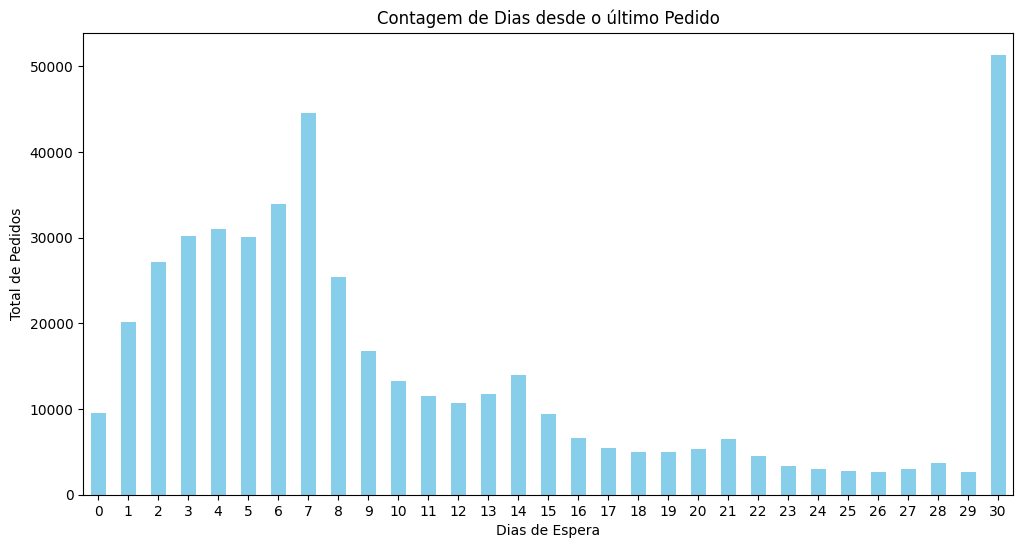

O tempo mínimo de espera é 0.0 dias
O tempo máximo de espera é 30.0 dias
Contagem de Dias desde o último pedido:
0      9589
1     20179
2     27138
3     30224
4     31006
5     30096
6     33930
7     44577
8     25361
9     16753
10    13309
11    11467
12    10658
13    11737
14    13992
15     9416
16     6587
17     5498
18     4971
19     4939
20     5302
21     6448
22     4514
23     3337
24     3015
25     2711
26     2640
27     2986
28     3745
29     2673
30    51337
Name: days_since_prior_order, dtype: int64


In [ ]:
# Verificando os dias máximos e minimos
dias_minimos = instacart_orders['days_since_prior_order'].min()
dias_maximos = instacart_orders['days_since_prior_order'].max()

# Criando a variável para extrair a contagem do tempo em dias.
dias_sem_vlr_ausentes = instacart_orders['days_since_prior_order'].dropna().astype(int)
contagem_espera = dias_sem_vlr_ausentes.value_counts().sort_index()

# Criando um gráfico para ver quanto tempo as pessoas esperam para fazer um novo pedido
plt.figure(figsize= (12, 6))
contagem_espera.plot(kind= 'bar', color= 'skyblue')

# Adicionando o titulo e os rótulos
plt.title('Contagem de Dias desde o último Pedido')
plt.xlabel('Dias de Espera')
plt.ylabel('Total de Pedidos')
plt.xticks(rotation=0)

# Exibindo o gráfico
plt.show()

# Imprimindo os resultados para minimo e máximo.
print(f'O tempo mínimo de espera é {dias_minimos} dias')
print(f'O tempo máximo de espera é {dias_maximos} dias')
print('============================')
print('Contagem de Dias desde o último pedido:')
print(contagem_espera)

Escreva suas conclusões aqui
- Podemos tirar algunas conclusões sobre o resultado desses dados mostrados no gráfico.
- Podemos ver que existe uma frequência de pico (ainda que leve) semanal. Vemos isso com picos em 7, 14, 21 e 28 dias.
- Podemos observar também que a quantidade de clientes que fizeram mais de uma compra no mesmo dia que é o dia 0, tendo 9589.
- Outro ponto importante é ver que o valor para 30 dias é muito elevado, supondo que o sistema faz um truncamento ao chegar em 30 dias, ou seja, ele apenas acumula em 30 dias, entendendo que não ha dia 31. 32 e continuo.
- O tempo minimo de espera é 0 enquanto o tempo máximo é 30 dias.

# [B] Médio (é necessário concluir tudo para passar)
1. Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.

### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

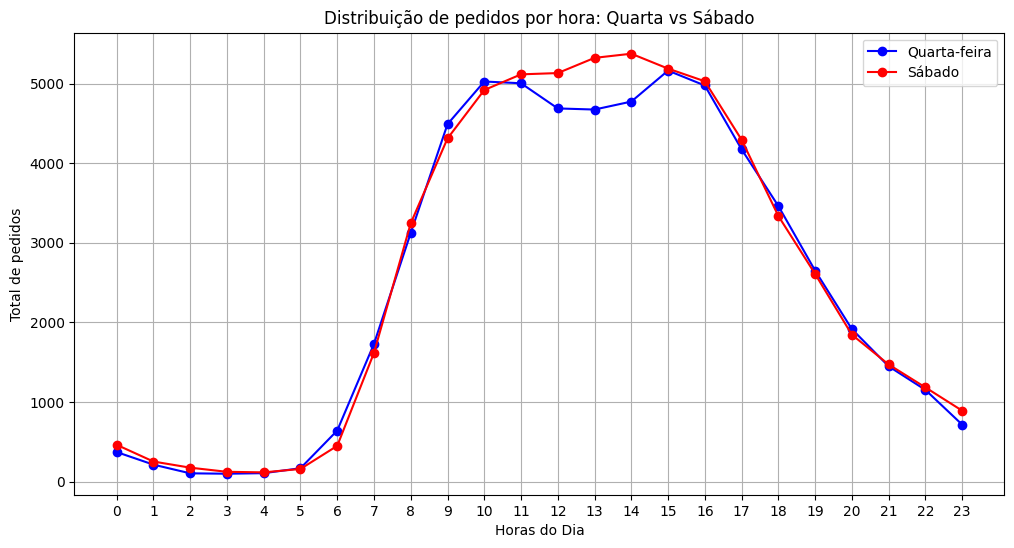

In [ ]:
# Filtrando os dados pelos dias especificos
quarta = instacart_orders[instacart_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
sabado = instacart_orders[instacart_orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

# Criando o gráfico de linhas para comparar a diferença entre quartas e sábados
plt.figure(figsize=(12, 6))
plt.plot(quarta.index, quarta.values, label= 'Quarta-feira', color= 'blue', marker= 'o')
plt.plot(sabado.index, sabado.values, label = 'Sábado', color= 'red', marker= 'o')

# Criando titulos e rótulos
plt.title('Distribuição de pedidos por hora: Quarta vs Sábado')
plt.xlabel('Horas do Dia')
plt.ylabel('Total de pedidos')
plt.xticks(range(24))
plt.grid()
plt.legend() # Criando a legenda
plt.show()

Escreva suas conclusões aqui
- Podemos observar que a tendência entre os dias de quarta e sábado são praticamente os mesmos para os pedidos.
- Tanto nas quartas como nos sábados os pedidos começam aos poucos no inicio do dia e vão aumentando ao passar das horas, declinando após a hora 16 para as últimas horas do dia.
- A principal diferença é em relação ao horário de pico dos dois dias. Entre as horas 10 e 15, aos sábados tem um aumento dos pedidos nesse horário enquanto as quartas tem uma curva em U, com um leve declinio em relação aos sábados durante esses horários.
    

### [B2] Qual é a distribuição do número de pedidos por cliente?

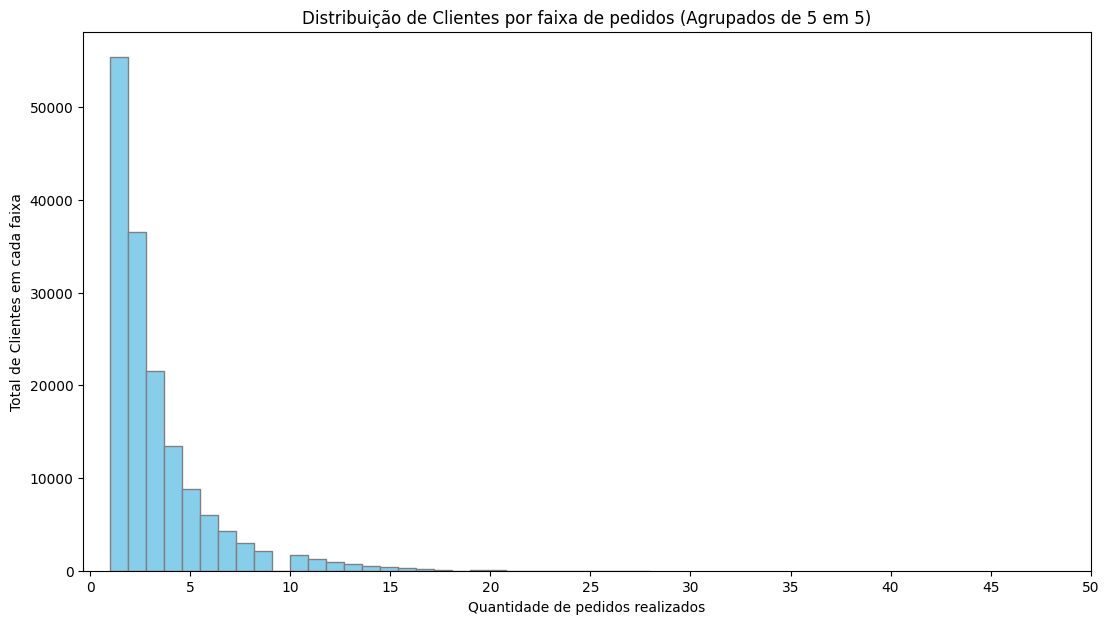

In [ ]:

# Primeiro, descobrimos o total de pedidos de cada cliente
# Agrupamos por ID do usuário e pegamos o número do último pedido (o maior)
pedidos_por_cliente = instacart_orders.groupby('user_id')['order_number'].count()

# Criando um histógrama
plt.figure(figsize= (13, 7))
plt.hist(pedidos_por_cliente, bins= 30, color= 'skyblue', edgecolor= 'gray')

# Criando o titulo e rótulos
plt.title('Distribuição de Clientes por faixa de pedidos (Agrupados de 5 em 5)')
plt.xlabel('Quantidade de pedidos realizados')
plt.ylabel('Total de Clientes em cada faixa')
plt.xticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
plt.show()

Escreva suas conclusões aqui
- A distribuição de pedidos para a quantidade de clientes está muito concentrada entre 0 e 5 pedidos, com valores que ultrapassam os 50 mil pedidos nos primeiros pedidos.
- A quantidade cai considerávelmente a medida que os pedidos vão aumentando, entendendo-se uma prática comum em aplicativos de entrega. A maioria das pessoas que fazem pedido por aplicativo, fazem pedidos para testar o aplicativo, para ver se funciona, se a entrega é rápida e eficiênte. Enquanto quem faz muitos pedidos, são aqueles que já testaram e foram fidelizados, comprando constantemente.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [ ]:
# Contando quantas vezes cada product_id aparece no DataFrame order_products
# O head(20) traz os 20 maiores valores, resetando o index e inserindo nomes para colunas
top_20_contagem = order_products['product_id'].value_counts().reset_index().head(20)
top_20_contagem.columns = ['product_id', 'quantidade_vendas']

# Fazemos a junção com a tabela de produtos para obter os nomes
# Selecionamos apenas as colunas product_id e product_name de products
top_20_contagem = top_20_contagem.merge(products[['product_id', 'product_name']], on='product_id')

# Exibindo o resultado final ordenado pela maior quantidade
print('Os 20 produtos comprados com mais frequência:')
print(top_20_contagem[['product_id', 'product_name', 'quantidade_vendas']])

Os 20 produtos comprados com mais frequência:
    product_id              product_name  quantidade_vendas
0        24852                    banana              66050
1        13176    bag of organic bananas              53297
2        21137      organic strawberries              37039
3        21903      organic baby spinach              33971
4        47209      organic hass avocado              29773
5        47766           organic avocado              24689
6        47626               large lemon              21495
7        16797              strawberries              20018
8        26209                     limes              19690
9        27845        organic whole milk              19600
10       27966       organic raspberries              19197
11       22935      organic yellow onion              15898
12       24964            organic garlic              15292
13       45007          organic zucchini              14584
14       39275       organic blueberries              

Escreva suas conclusões aqui
- Podemos tirar algumas insights interessantes:
- E vimos que a lista dos 20 produtos que mais saem com frequência são frutas, verduras e vegetais, reforçando a tese anterior de uma assiduidade de pedidos semanais e frequentes por conta que esses produtos são perecíveis e frescos, sendo consumidos em poucos dias.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)
1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.

### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

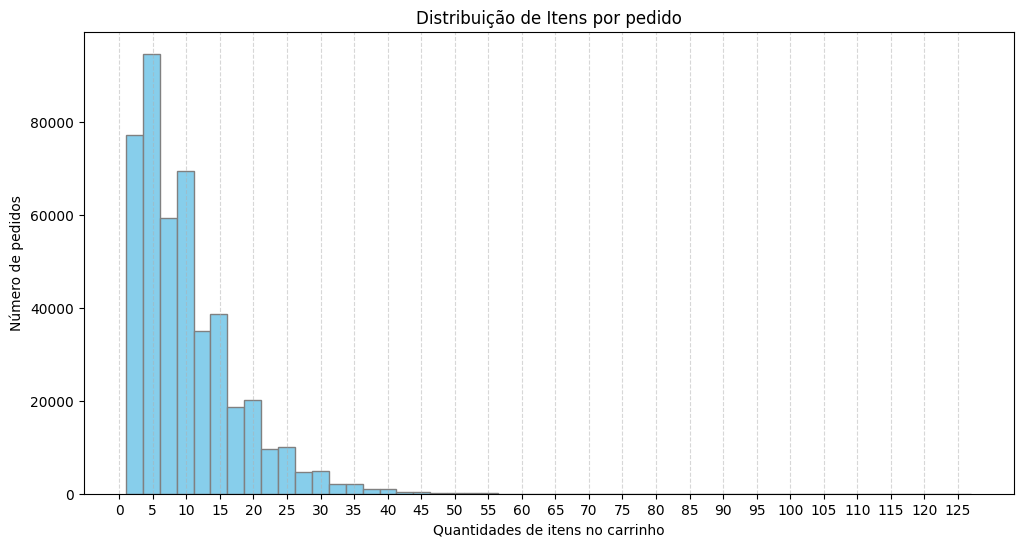

Média de itens por pedido: 10.10
Máximo de itens em um único pedido: 127


In [ ]:
# Agrupando os pedidos e contando os produtos
itens_por_pedido = order_products.groupby('order_id')['product_id'].count()

# Criando o gráfico
plt.figure(figsize= (12, 6))
itens_por_pedido.plot(kind= 'hist', bins= 50, color= 'skyblue', edgecolor= 'gray')

# Criando o titulo e rótulos
plt.title('Distribuição de Itens por pedido')
plt.xlabel('Quantidades de itens no carrinho')
plt.ylabel('Número de pedidos')
plt.xticks(range(0, 130, 5))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

# Imprimindo os resultados
print(f"Média de itens por pedido: {itens_por_pedido.mean():.2f}")
print(f"Máximo de itens em um único pedido: {itens_por_pedido.max()}")

Escreva suas conclusões aqui
- Observa-se que a quantidade de itens no carrinho é maior entre 5 a 10, tendo um declinio considerável com a quantidade de itens mais baixo.
- A média de itens por pedido é de 10.10 e a quantidade máxima de itens em um único pedido foi de 127.

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [ ]:
# Filtrando os itens pelo reordered
reordenados = order_products[order_products['reordered'] == 1]

# Contando os 20 IDs mais frequêntes
top_20_ids_reordenados = reordenados['product_id'].value_counts().head(20).reset_index()
# Atribuindo nomes para as colunas
top_20_ids_reordenados.columns = ['product_id', 'total_reordenado']

# Trazendo as colunas do DataFrame products
top_20_ids_reordenados_final = top_20_ids_reordenados.merge(products[['product_id', 'product_name']], on= 'product_id')

# Imprimindo
print(top_20_ids_reordenados_final)

    product_id  total_reordenado              product_name
0        24852             55763                    banana
1        13176             44450    bag of organic bananas
2        21137             28639      organic strawberries
3        21903             26233      organic baby spinach
4        47209             23629      organic hass avocado
5        47766             18743           organic avocado
6        27845             16251        organic whole milk
7        47626             15044               large lemon
8        27966             14748       organic raspberries
9        16797             13945              strawberries
10       26209             13327                     limes
11       22935             11145      organic yellow onion
12       24964             10411            organic garlic
13       45007             10076          organic zucchini
14       49683              9538            cucumber kirby
15       28204              8989        organic fuji app

Escreva suas conclusões aqui
- Os 20 principais itens que são incluidos com mais frequência em pedidos repetidos são os hortfruts.
- Muitos deles são orgânicos, com forte tendência para pessoas que cuidam da saúde e consomem itens frescos e naturais.

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [ ]:

# Calculamos o total de pedidos por produto e o total de reordenados
total_pedidos_prod = order_products.groupby('product_id')['reordered'].count()
total_reord_prod = order_products.groupby('product_id')['reordered'].sum()

# Calculando a proporção
proporcao_prod = (total_reord_prod / total_pedidos_prod).reset_index()
proporcao_prod.columns = ['product_id', 'proporcao_reordenados']

# Juntando ao Dataframe products com o merge
tabela_final = proporcao_prod.merge(products[['product_id', 'product_name']], on= 'product_id')


# Maiores taxas (Os 20 produtos com mais fidelidade)
print("Top 20 - Maior proporção de repetidos:")
print(tabela_final.sort_values(by='proporcao_reordenados', ascending=False).head(20))

print("\n" + "="*50 + "\n")

# Menores taxas (Os produtos que não geraram repetição)
print("Top 20 - Menor proporção de repetidos:")
print(tabela_final.sort_values(by='proporcao_reordenados', ascending=True).head(20))


Top 20 - Maior proporção de repetidos:
       product_id  proporcao_reordenados  \
13453       14721                    1.0   
19195       20949                    1.0   
6136         6723                    1.0   
6144         6732                    1.0   
41319       45088                    1.0   
41310       45078                    1.0   
19258       21016                    1.0   
19248       21005                    1.0   
32273       35192                    1.0   
32277       35197                    1.0   
6211         6810                    1.0   
41274       45040                    1.0   
41269       45035                    1.0   
25120       27373                    1.0   
28203       30748                    1.0   
41265       45031                    1.0   
32224       35137                    1.0   
28202       30747                    1.0   
32304       35228                    1.0   
32305       35229                    1.0   

                                    

Escreva suas conclusões aqui
- Extremos da Distribuição: A análise mostra que a fidelidade não é uniforme. Existem produtos com taxa de 1.0 (100%), o que indica que todos os clientes que o compraram, voltaram a comprar. Geralmente, são itens muito específicos ou de nicho que atendem a uma necessidade contínua.
- A Realidade dos 0.0: Os itens com proporção zero são produtos de baixa recorrência. No seu laudo, você pode explicar que isso é esperado para itens que não são de consumo rápido (como utensílios) ou produtos novos que ainda não tiveram tempo de ter um segundo ciclo de compra no dataset.
- Conclusão Estratégica: O investidor deve olhar para a tabela de maiores taxas como o "coração" da retenção da plataforma, enquanto a tabela de menores taxas serve para identificar produtos que podem estar com problemas de qualidade ou que simplesmente não fazem sentido para compras recorrentes.

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [ ]:
# Unindo o DataFrame order_products com os pedidos para ter o user_id
df_user_items = order_products.merge(instacart_orders[['order_id', 'user_id']], on= 'order_id')

# Calculando a proporção por usuários
proporcao_por_cliente = df_user_items.groupby('user_id')['reordered'].mean().reset_index()
proporcao_por_cliente.columns = ['user_id', 'proporcao_repetidos']

# Exibindo os primeiros 20 clientes para análise
print("Proporção de itens repetidos por cliente:")
print(proporcao_por_cliente.head(20))

# Para o seu resumo, vamos ver os extremos (clientes mais fiéis vs menos fiéis)
print("\nClientes com maior taxa de repetição (Fidelizados):")
print(proporcao_por_cliente.sort_values(by='proporcao_repetidos', ascending=False).head(10))

print("\nClientes com menor taxa de repetição (Exploradores):")
print(proporcao_por_cliente.sort_values(by='proporcao_repetidos', ascending=True).head(10))


Proporção de itens repetidos por cliente:
    user_id  proporcao_repetidos
0         2             0.038462
1         4             0.000000
2         5             0.666667
3         6             0.000000
4         7             0.928571
5        11             0.200000
6        12             0.250000
7        13             0.565217
8        14             0.360656
9        15             0.538462
10       16             0.531250
11       17             0.716981
12       19             0.291667
13       20             0.000000
14       21             0.400000
15       22             1.000000
16       24             0.500000
17       26             0.437500
18       27             0.658824
19       28             0.500000

Clientes com maior taxa de repetição (Fidelizados):
        user_id  proporcao_repetidos
99672    137587                  1.0
125732   173474                  1.0
10138     13918                  1.0
45067     62300                  1.0
45074     62307            

Escreva suas conclusões aqui
- Clientes com proporção alta (perto de 1.0) são "compradores de rotina" que repõem estoque fixo, garantindo receita estável. Já valores baixos indicam novos usuários ou "exploradores" que ainda não criaram hábitos. Para o investidor, essa métrica define a saúde da retenção da plataforma.

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [ ]:
# Filtrando apenas os itens que foram adicionados na posição 1 do carrinho
primeiros_add = order_products[order_products['add_to_cart_order'] == 1]

# Contando quantas vezes cada 'product_id' foi o primeiro a ser escolhido
top_20_primeiros = primeiros_add['product_id'].value_counts().head(20).reset_index()
top_20_primeiros.columns = ['product_id', 'vezes_em_primeiro']

# Agregando os nomes dos produtos (Merge)
# Cruzamos com a tabela products para substituir o ID pelo nome real
top_20_prioridade = top_20_primeiros.merge(products[['product_id', 'product_name']], on= 'product_id')

# Exibindo o resultado final para o seu laudo técnico
print("Top 20 Itens de Prioridade (Os primeiros a entrar no carrinho):")
print(top_20_prioridade[['product_id', 'product_name', 'vezes_em_primeiro']])

Top 20 Itens de Prioridade (Os primeiros a entrar no carrinho):
    product_id                 product_name  vezes_em_primeiro
0        24852                       banana              15562
1        13176       bag of organic bananas              11026
2        27845           organic whole milk               4363
3        21137         organic strawberries               3946
4        47209         organic hass avocado               3390
5        21903         organic baby spinach               3336
6        47766              organic avocado               3044
7        19660                 spring water               2336
8        16797                 strawberries               2308
9        27966          organic raspberries               2024
10       44632   sparkling water grapefruit               1914
11       49235          organic half & half               1797
12       47626                  large lemon               1737
13         196                         soda           

Escreva suas conclusões aqui
- Foi identificado que os 20 principais itens que foram adicionados primeiramente no carrinho são itens de consumo recorrente. Produtos com frutas e verduras, ou seja, perecíveis.
- A banana é o carro chefe desses itens, estando muito a frente dos demais itens.

# Conclusão geral do projeto:

**Aqui estão os pontos fundamentais:**
- **Fidelização pelo Essencial:** O sucesso da plataforma reside nos produtos perecíveis (Hortifruti). O cruzamento de dados prova que itens como bananas e produtos orgânicos são os "motores" do app: eles são os mais vendidos, os que possuem maior taxa de recompra e, crucialmente, os primeiros a serem colocados no carrinho.
- **Hábito cíclico:** Os dados de tempo revelam que o consumidor tem um comportamento extremamente previsível, com ciclos de recompra fechados de 7 dias. Isso mostra que a plataforma conseguiu se integrar à rotina doméstica, tornando-se uma ferramenta de abastecimento semanal.
- **Dualidade de Clientes:** O cruzamento entre usuários e pedidos identifica dois grupos claros: uma base sólida de Power Users (altíssima fidelidade e repetição) e uma grande massa de Exploradores (compras únicas e baixa repetição). O desafio do negócio não é atrair novos clientes, mas converter exploradores em usuários de rotina.
**Conclusão** Estratégica: A plataforma é movida pela necessidade imediata e recorrência. Para o investidor, o valor real não está no mix de produtos variados, mas na eficiência em entregar o "básico" (perecíveis) com constância, pois é isso que garante o fluxo de caixa semanal e a retenção do usuário.